In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import pandas as pd

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device: ",device)
# -----------------------------
# Basic Residual Block
# -----------------------------
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride,
            padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1,
            padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels,
                    kernel_size=1, stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out


# -----------------------------
# Custom ResNet-16
# -----------------------------
class ResNet16(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 16

        self.conv1 = nn.Conv2d(
            3, 16, kernel_size=3,
            stride=1, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(16)

        # 7 residual blocks total
        self.layer1 = self._make_layer(16, 3, stride=1)
        self.layer2 = self._make_layer(32, 2, stride=2)
        self.layer3 = self._make_layer(64, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels, blocks, stride):
        layers = []

        layers.append(
            BasicBlock(self.in_channels, out_channels, stride)
        )
        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(self.in_channels, out_channels)
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = torch.relu(self.bn1(self.conv1(x)))

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x


# -----------------------------
# Data Augmentation (paper)
# -----------------------------
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010)
    )
])


# -----------------------------
# Dataset
# -----------------------------
full_trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    full_trainset,
    [train_size, val_size]
)

val_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(testset, batch_size=128, shuffle=False)


# -----------------------------
# Training Setup (paper)
# -----------------------------
model = ResNet16().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=[91, 136],
    gamma=0.1
)

num_epochs = 182


# -----------------------------
# Print parameters
# -----------------------------
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")
print(f"In Millions: {total_params/1e6:.3f} M")

Using device:  cuda
Total Parameters: 179,930
In Millions: 0.180 M


Epoch   1/182 | LR: 0.1000 | Train Loss: 1.4916 | Train Acc: 44.31% | Val Loss: 1.3901 | Val Acc: 51.94%
Epoch   2/182 | LR: 0.1000 | Train Loss: 0.9993 | Train Acc: 63.89% | Val Loss: 0.9908 | Val Acc: 64.58%
Epoch   3/182 | LR: 0.1000 | Train Loss: 0.8152 | Train Acc: 70.93% | Val Loss: 0.9201 | Val Acc: 68.20%
Epoch   4/182 | LR: 0.1000 | Train Loss: 0.6867 | Train Acc: 75.76% | Val Loss: 0.8250 | Val Acc: 71.66%
Epoch   5/182 | LR: 0.1000 | Train Loss: 0.5905 | Train Acc: 79.48% | Val Loss: 0.7686 | Val Acc: 74.24%
Epoch   6/182 | LR: 0.1000 | Train Loss: 0.5274 | Train Acc: 81.60% | Val Loss: 0.7307 | Val Acc: 76.00%
Epoch   7/182 | LR: 0.1000 | Train Loss: 0.4743 | Train Acc: 83.48% | Val Loss: 0.7643 | Val Acc: 76.22%
Epoch   8/182 | LR: 0.1000 | Train Loss: 0.4330 | Train Acc: 84.96% | Val Loss: 0.8509 | Val Acc: 73.00%
Epoch   9/182 | LR: 0.1000 | Train Loss: 0.3911 | Train Acc: 86.34% | Val Loss: 0.8036 | Val Acc: 75.40%
Epoch  10/182 | LR: 0.1000 | Train Loss: 0.3601 | Train

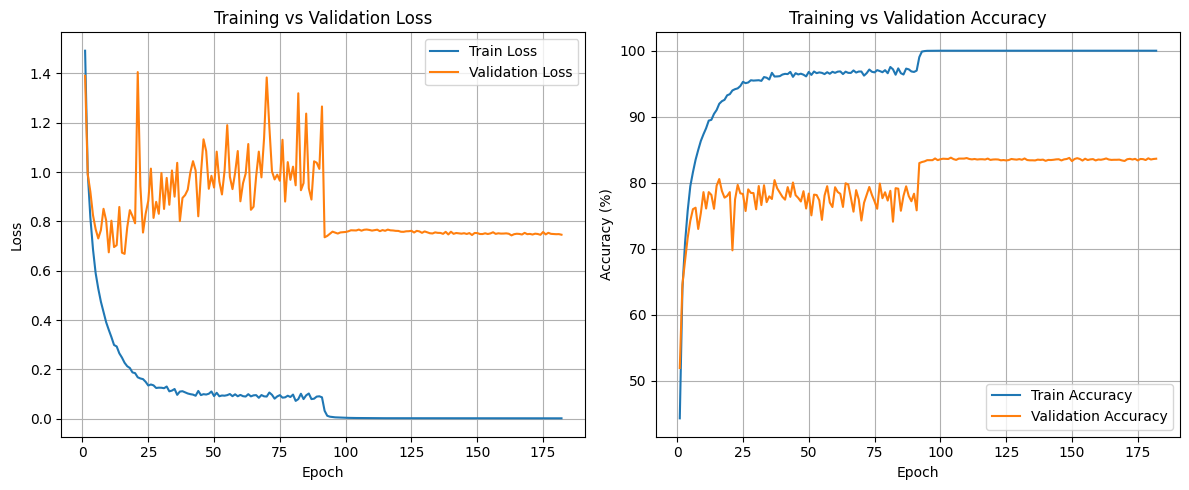

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
# -----------------------------
# Store history
# -----------------------------
history = {
    "Epoch": [],
    "Train Loss": [],
    "Train Accuracy": [],
    "Validation Loss": [],
    "Validation Accuracy": [],
    "Learning Rate": []
}


# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            total_loss += loss.item()

            _, predicted = outputs.max(1)

            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


# -----------------------------
# Train One Epoch
# -----------------------------
def train_epoch():
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = outputs.max(1)

        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    return avg_loss, accuracy


# -----------------------------
# Training Loop
# -----------------------------
for epoch in range(1, num_epochs + 1):

    train_loss, train_acc = train_epoch()
    val_loss, val_acc = evaluate(val_loader)

    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history["Epoch"].append(epoch)
    history["Train Loss"].append(train_loss)
    history["Train Accuracy"].append(train_acc)
    history["Validation Loss"].append(val_loss)
    history["Validation Accuracy"].append(val_acc)
    history["Learning Rate"].append(current_lr)

    print(
        f"Epoch {epoch:3d}/{num_epochs} | "
        f"LR: {current_lr:.4f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    scheduler.step()


# -----------------------------
# Save to Excel
# -----------------------------
df = pd.DataFrame(history)

excel_file = "resnet16_cifar10_results.xlsx"
df.to_excel(excel_file, index=False)

print(f"\nTraining history saved to: {excel_file}")


# -----------------------------
# Final Test Evaluation
# -----------------------------
test_loss, test_acc = evaluate(test_loader)

print("\nFinal Test Results")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")
print(f"Test Error    : {100 - test_acc:.2f}%")


# -----------------------------
# Plot Graphs
# -----------------------------
epochs = history["Epoch"]

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history["Train Loss"], label="Train Loss")
plt.plot(epochs, history["Validation Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history["Train Accuracy"], label="Train Accuracy")
plt.plot(epochs, history["Validation Accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()